# Flexural stiffness of offset circular layers

This notebook computes only the flexural stiffness of a composite cross section
made from circular layers with different elastic moduli. Each layer is the
region between two adjacent circular boundaries, and those boundary circles
can be vertically offset from one another.

In [1]:
# Import numerical and plotting tools
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import numpy as np

# Use TeX-rendered serif typography for publication figures
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 11,
    "font.size": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## Offset circular layer model

For bending about the horizontal neutral axis, the composite flexural
stiffness is defined by the cross-section integral

$$
EI = \int_A E(y,z)\left(y-y_\mathrm{NA}\right)^2\,dA,
$$

where $E(y,z)$ is the local elastic modulus and $y_\mathrm{NA}$ is the
vertical position of the elastic neutral axis measured from the origin. The
neutral axis is determined by the zero axial-force condition under pure
bending,

$$
\int_A E(y,z)\left(y-y_\mathrm{NA}\right)\,dA = 0,
$$

so that

$$
y_\mathrm{NA} = \frac{\int_A E(y,z)y\,dA}{\int_A E(y,z)\,dA}.
$$

The notebook evaluates these integrals for $N$ nested disks indexed by
$i=1,\ldots,N$. Disk $i$ has radius $R_i$, vertical centre offset $c_i$
measured from the origin, and elastic modulus $E_i$. For disk $i$, the area
$A_i^D$, first moment of area $Q_i^D$, and second moment of area $I_i^D$
about the origin are

$$
A_i^D = \pi R_i^2,
\qquad
Q_i^D = A_i^D c_i,
\qquad
I_i^D = \frac{\pi}{4} R_i^4 + A_i^D c_i^2.
$$

where the last expression uses the parallel-axis theorem to shift the disk
second moment to the origin. Material layer $i$ is the region inside disk
$i$ after removing disk $i-1$, and has area $A_i$, first moment of area
$Q_i$, and second moment of area $I_i^0$ about the origin given by

$$
A_i = A_i^D - A_{i-1}^D,
\qquad
Q_i = Q_i^D - Q_{i-1}^D,
\qquad
I_i^0 = I_i^D - I_{i-1}^D,
$$
where $A_0^D = Q_0^D = I_0^D = 0$ for the empty disk.
The centroid and centroidal second moment of area of layer $i$ are

$$
y_i = \frac{Q_i}{A_i},
\qquad
I_i^c = I_i^0 - A_i y_i^2.
$$

Using the assumption that each layer has a constant elastic modulus, the integral definitions for the composite cross-section then reduce to

$$
y_\mathrm{NA} = \frac{\sum_i E_i A_i y_i}{\sum_i E_i A_i},
\qquad
EI = \sum_i E_i \int_{A_i} (y-y_{\mathrm{NA}})^2\,dA = \sum_i E_i \left(I_i^c + A_i (y_i-y_\mathrm{NA})^2\right).
$$

In [2]:
def calculate_flexural_stiffness(
    disk_radii: np.ndarray,
    disk_offsets: np.ndarray,
    elastic_moduli: np.ndarray,
) -> tuple[float, float]:
    """Return the neutral-axis position and flexural stiffness."""
    disk_radii = np.asarray(disk_radii, dtype=float)
    disk_offsets = np.asarray(disk_offsets, dtype=float)
    elastic_moduli = np.asarray(elastic_moduli, dtype=float)

    # Compute disk moments about the origin
    disk_areas = np.pi * disk_radii**2
    disk_first_moments = disk_areas * disk_offsets
    disk_centroidal_second_moments = np.pi * disk_radii**4 / 4.0
    disk_second_moments = (
        disk_centroidal_second_moments + disk_areas * disk_offsets**2
    )

    # Subtract the previous disk to get layer properties
    inner_disk_areas = np.concatenate(([0.0], disk_areas[:-1]))
    inner_disk_first_moments = np.concatenate(([0.0], disk_first_moments[:-1]))
    inner_disk_second_moments = np.concatenate(([0.0], disk_second_moments[:-1]))

    areas = disk_areas - inner_disk_areas
    first_moments = disk_first_moments - inner_disk_first_moments
    second_moments = disk_second_moments - inner_disk_second_moments

    # Locate layer centroids and the neutral axis
    layer_centroid_positions = first_moments / areas
    centroidal_second_moments = second_moments - areas * layer_centroid_positions**2
    axial_stiffness_weights = elastic_moduli * areas
    neutral_axis_position = np.sum(
        axial_stiffness_weights * layer_centroid_positions
    )
    neutral_axis_position /= np.sum(axial_stiffness_weights)

    # Shift layer second moments from layer centroids to the neutral axis
    layer_centroid_offsets = layer_centroid_positions - neutral_axis_position
    neutral_axis_second_moments = (
        centroidal_second_moments + areas * layer_centroid_offsets**2
    )
    layer_flexural_stiffnesses = elastic_moduli * neutral_axis_second_moments
    flexural_stiffness = np.sum(layer_flexural_stiffnesses)

    return float(neutral_axis_position), float(flexural_stiffness)

## Calculate flexural stiffness for a specific cross-section

Here we calculate the flexural stiffness for a specific cross-section with
three layers, representing pith, vascular tissue, and ground tissue.

In [3]:
# Define the disk radii, vertical offsets from the origin, elastic moduli, and colors
disk_names = ("Pith", "Vascular tissue", "Ground tissue")
disk_colors = ("#f2c94c", "#8ecae6", "#9b5de5")

disk_radii = np.array((0.006, 0.011, 0.015))
disk_offsets = np.array((0.0, 0.0, -0.003))
elastic_moduli = np.array((12.0e6, 35.0e6, 8.0e6))

# Compute the neutral axis and flexural stiffness
neutral_axis_position, flexural_stiffness = calculate_flexural_stiffness(
    disk_radii,
    disk_offsets,
    elastic_moduli,
)

print(f"Neutral axis position from origin = {neutral_axis_position:.6e} m")
print(f"Flexural stiffness EI = {flexural_stiffness:.6e} N m^2")

Neutral axis position from origin = -1.273885e-03 m
Flexural stiffness EI = 6.344313e-01 N m^2


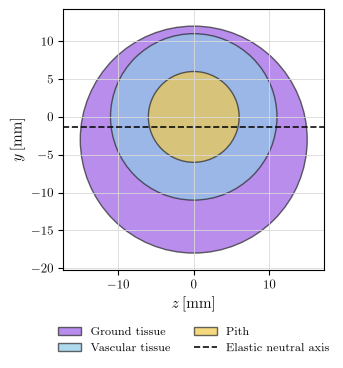

In [4]:
# Draw the offset circular disk cross section
fig, ax = plt.subplots(figsize=(6.5, 4.5))
disk_count = len(disk_radii)

# Convert metre-scale geometry to millimetres for plotting
plot_disk_radii = 1.0e3 * disk_radii
plot_disk_offsets = 1.0e3 * disk_offsets
plot_neutral_axis_position = 1.0e3 * neutral_axis_position

for i in range(disk_count - 1, -1, -1):
    disk = Circle(
        xy=(0.0, plot_disk_offsets[i]),
        radius=plot_disk_radii[i],
        facecolor=disk_colors[i],
        edgecolor="0.15",
        alpha=0.70,
        linewidth=1.0,
        label=disk_names[i],
    )
    ax.add_patch(disk)

# Draw the computed elastic neutral axis
lower_y_limit = min(
    0.0,
    plot_neutral_axis_position,
    np.min(plot_disk_offsets - plot_disk_radii),
)
upper_y_limit = max(
    0.0,
    plot_neutral_axis_position,
    np.max(plot_disk_offsets + plot_disk_radii),
)
y_centre = 0.5 * (lower_y_limit + upper_y_limit)
y_half_width = 0.575 * (upper_y_limit - lower_y_limit)
axis_extent = max(1.15 * np.max(plot_disk_radii), y_half_width)

ax.axhline(
    plot_neutral_axis_position,
    color="0.05",
    linestyle="--",
    linewidth=1.2,
    label=r"Elastic neutral axis",
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-axis_extent, axis_extent)
ax.set_ylim(y_centre - axis_extent, y_centre + axis_extent)
ax.set_xlabel(r"$z\,[\mathrm{mm}]$")
ax.set_ylabel(r"$y\,[\mathrm{mm}]$")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    borderaxespad=0.0,
    frameon=False,
    fontsize="small",
    ncol=2,
)
ax.grid(True, color="0.85", linewidth=0.6)

fig.tight_layout(rect=(0.0, 0.12, 1.0, 1.0))
plt.show()